In [1]:
import warnings
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

from category_encoders import TargetEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.linear_model import Ridge, Lasso

from sklearn.utils.validation import check_is_fitted
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
import statsmodels.api as sm

from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_predict

from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

import shap
from sklearn.feature_selection import RFE, RFECV

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["OMP_NUM_THREADS"] = "4"

# SET UP

In [2]:
linear_reg = LinearRegression()
tree_reg = DecisionTreeRegressor()
forest_reg = RandomForestRegressor()
svr_reg = SVR()

In [3]:
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols
        self.encoder = TargetEncoder(cols=cols)

    def fit(self, X, y):
        self.encoder.fit(X, y)
        return self

    def transform(self, X):
        return self.encoder.transform(X)

In [4]:
class StatsmodelsOLS(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        X = sm.add_constant(X)
        self.model_ = sm.OLS(y, X).fit()
        self.X_columns_ = X.columns if hasattr(X, 'columns') else None
        return self

    def predict(self, X):
        X = sm.add_constant(X)
        return self.model_.predict(X)

    def summary(self):
        return self.model_.summary()

In [5]:
df = pd.read_csv(r"C:\Users\jfurs\@Python\OpenClassrooms\DS\P4\emissions\df_emissions.csv")

In [6]:
tgt_enc_features = ["PrimaryPropertyType"]
cat_features = ['building_age_category', 'building_height_category']
to_scale_features = ["PropertyGFABuilding(s)","PropertyGFATotal"]

tgt_enc_transformer = Pipeline([
    ("tgt_enc", TargetEncoderWrapper(cols=tgt_enc_features))
])

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
    ])

categorical_transformer = Pipeline([
    ('encoder', OrdinalEncoder())
    ])

preprocessor = ColumnTransformer([
    ("t_enc", tgt_enc_transformer, tgt_enc_features), 
    ('num', numeric_transformer, to_scale_features),
    ('cat', categorical_transformer, cat_features),
    ], remainder='passthrough')

# DATA IMPUTATTION

In [7]:
X = df.copy()
y = df["TotalGHGEmissions"]
X_scaled = preprocessor.fit_transform(X,y)
y_ = df["ENERGYSTARScore"].dropna()
X_scaled_ = pd.DataFrame(X_scaled, columns=X.columns)

In [8]:
X_scld = X_scaled_.dropna()
X_train, X_test, y_train, y_test = train_test_split(X_scld, y_, test_size=0.2, random_state=42)

In [9]:
max_k = 15
scores = []
for k in range(1, max_k):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    scores.append(rmse)

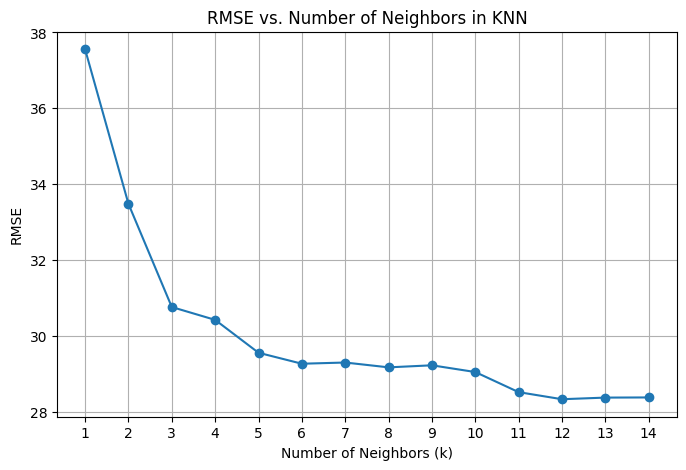

Optimal K is 12 with a RMSE of 28.334402999810447


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k), scores, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('RMSE')
plt.title('RMSE vs. Number of Neighbors in KNN')
plt.xticks(range(1, max_k))
plt.grid(True)
plt.show()

min_value = min(scores)
min_index = scores.index(min_value)

print(f"Optimal K is {min_index+1} with a RMSE of {min_value}")

In [11]:
np.mean(df["ENERGYSTARScore"])

np.float64(63.671370967741936)

In [12]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Fit OLS model
linear_model = sm.OLS(y_train, X_train_sm).fit()

# Print summary
print(linear_model.summary())

# Predict on test set
y_pred_sm = linear_model.predict(X_test_sm)
rmse_sm = root_mean_squared_error(y_test, y_pred_sm)

# # Calculate RMSE
print(f"OLS Linear Regression RMSE: {rmse_sm}")

                            OLS Regression Results                            
Dep. Variable:        ENERGYSTARScore   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.446e+24
Date:                Sat, 10 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:01:15   Log-Likelihood:                 16884.
No. Observations:                 793   AIC:                        -3.374e+04
Df Residuals:                     778   BIC:                        -3.367e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
NumberofBuildings       

Impossible d'avoir des valeurs cohérentes avec l'imputation statistique car :
- Avec KNN, la valeur de l'erreur moyenne se situerai à 43%
- Avec la Régression Linéaire, les p-Values sont trop élevées

On enlève alors ENERGYSTAR Score des features

# SUITE SET UP

In [13]:
# train test for emissions
df = df.drop(columns=["SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)"])
X = df.drop(['TotalGHGEmissions', "ENERGYSTARScore"], axis=1)
y = df['TotalGHGEmissions']

y = np.sign(y) * np.log1p(np.abs(y))

In [14]:
np.mean(y)

np.float64(3.994612306942252)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [16]:
tgt_enc_features = ["PrimaryPropertyType"]
cat_features = ['building_age_category', 'building_height_category']
to_scale_features = ["PropertyGFABuilding(s)","PropertyGFATotal"]

tgt_enc_transformer = Pipeline([
    ("tgt_enc", TargetEncoderWrapper(cols=tgt_enc_features))
])

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
    ])

categorical_transformer = Pipeline([
    ('encoder', OrdinalEncoder())
    ])

preprocessor = ColumnTransformer([
    ("t_enc", tgt_enc_transformer, tgt_enc_features), 
    ('num', numeric_transformer, to_scale_features),
    ('cat', categorical_transformer, cat_features),
    ], remainder='passthrough')

# NON LINEAR PREDICTIONS

In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Tracking
nl_cv_scores = {}
nl_best_model = None
nl_best_score = -np.inf
nl_best_params = None
nl_best_model_name = ""

In [18]:
non_linear_model_configs = [
    {
        "name": "SVR_rbf",
        "estimator": SVR(kernel='rbf'),
        "param_grid": {
            "regressor__C": [0.1, 1, 10, 100],
            "regressor__gamma": ['scale', 'auto', 0.01, 0.1, 1],
            "regressor__epsilon": [0.01, 0.1, 0.2, 0.5]
        }
    },
    {
        "name": "XGBRegressor",
        "estimator": XGBRegressor(random_state=42, verbosity=0),
        "param_grid": {
            "regressor__n_estimators": [100, 200, 300],
            "regressor__max_depth": [3, 5, 7, 10],
            "regressor__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "regressor__subsample": [0.6, 0.8, 1.0],
            "regressor__colsample_bytree": [0.6, 0.8, 1.0],
            "regressor__gamma": [0, 0.1, 0.3, 1]
        }
    },
    {
        "name": "RandomForestRegressor",
        "estimator": RandomForestRegressor(random_state=42),
        "param_grid": {
            "regressor__n_estimators": [50, 100, 200, 300],
            "regressor__max_depth": [5, 10, 15, 20, None],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 4],
            "regressor__max_features": ['sqrt', 'log2', None]
        }
    }
]

In [19]:
for config in non_linear_model_configs:
    print(f"\n============= {config['name']} ===================")

    # Build pipeline
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', config["estimator"])
    ])

    # GridSearchCV
    grid = RandomizedSearchCV(
        estimator=full_pipeline,
        param_distributions=config["param_grid"],  # same dict, just renamed for clarity
        n_iter=20,  # You can set this to the number of random combinations you want to try
        cv=cv,
        scoring='r2',  # or 'neg_mean_squared_error'
        n_jobs=-1,
        random_state=42)
    
    grid.fit(X_train, y_train)
    mean_score = grid.best_score_

    # Use the best estimator to get cross-validated predictions
    best_estimator = grid.best_estimator_
    y_pred = cross_val_predict(best_estimator, X_train, y_train, cv=cv, n_jobs=-1)
    
    rmse = np.sqrt(root_mean_squared_error(y_train, y_pred))

    print(f"Best R²: {mean_score:.4f}")
    print(f"Best Params: {grid.best_params_}")
    print(f"RMSE: {rmse:.4f}")
    
    nl_cv_scores[config["name"]] = grid.cv_results_['mean_test_score']

    if mean_score > nl_best_score:
        nl_best_score = mean_score
        nl_best_model = grid.best_estimator_
        nl_best_params = grid.best_params_
        nl_best_model_name = config["name"]


============= SVR_rbf ===================


Best R²: 0.4477
Best Params: {'regressor__gamma': 'scale', 'regressor__epsilon': 0.5, 'regressor__C': 10}
RMSE: 1.0305

============= XGBRegressor ===================
Best R²: 0.5065
Best Params: {'regressor__subsample': 1.0, 'regressor__n_estimators': 200, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.05, 'regressor__gamma': 0.3, 'regressor__colsample_bytree': 1.0}
RMSE: 1.0012

============= RandomForestRegressor ===================
Best R²: 0.5024
Best Params: {'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': None, 'regressor__max_depth': 5}
RMSE: 1.0033


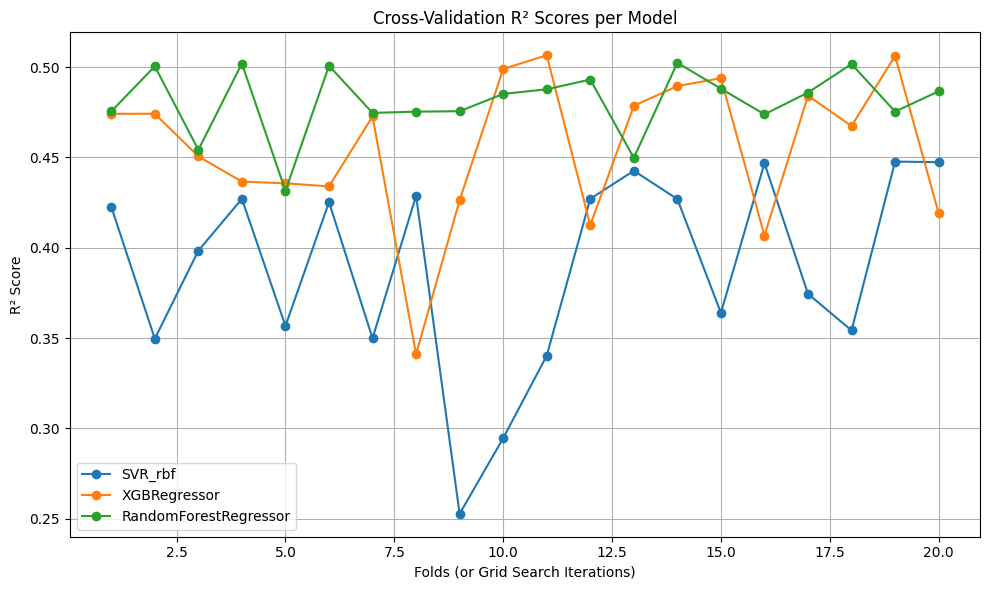


🏆 Best Model:
Model: XGBRegressor
Mean CV R²: 0.5065
Best Hyperparameters: {'regressor__subsample': 1.0, 'regressor__n_estimators': 200, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.05, 'regressor__gamma': 0.3, 'regressor__colsample_bytree': 1.0}


In [20]:
# Plot CV Scores
plt.figure(figsize=(10, 6))
for name, scores in nl_cv_scores.items():
    x = range(1, len(scores) + 1) 
    if isinstance(scores, list):
        plt.plot(x, scores, label=f"{name} (manual)", marker='o')
    else:
        plt.plot(x, scores, label=f"{name}", marker='o')

plt.title("Cross-Validation R² Scores per Model")
plt.xlabel("Folds (or Grid Search Iterations)")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the best model summary
print("\n🏆 Best Model:")
print(f"Model: {nl_best_model_name}")
print(f"Mean CV R²: {nl_best_score:.4f}")
if nl_best_params:
    print("Best Hyperparameters:", nl_best_params)

# LINEAR PREDICTIONS

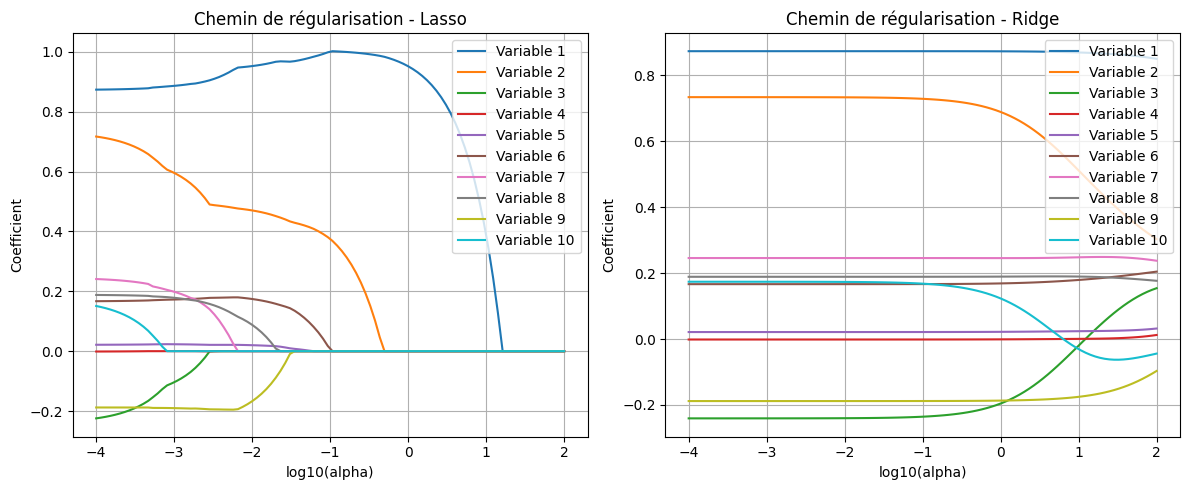

In [21]:
X_train_scaled = preprocessor.fit_transform(X_train, y_train)

alphas = np.logspace(-4, 2, 100)

def plot_two_regularization_paths(model_classes, model_names, X, y):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 ligne, 2 colonnes
    
    for ax, model_class, model_name in zip(axes, model_classes, model_names):
        coefs = []
        for alpha in alphas:
            model = model_class(alpha=alpha, fit_intercept=False, max_iter=10000)
            model.fit(X, y)
            coefs.append(model.coef_)

        coefs = np.array(coefs)
        for i in range(coefs.shape[1]):
            ax.plot(np.log10(alphas), coefs[:, i], label=f'Variable {i+1}')
        ax.set_xlabel('log10(alpha)')
        ax.set_ylabel('Coefficient')
        ax.set_title(f'Chemin de régularisation - {model_name}')
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_two_regularization_paths([Lasso, Ridge], ["Lasso", "Ridge"], X_train_scaled, y_train)

In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

l_cv_scores = {}
l_best_model = None
l_best_score = -np.inf
l_best_params = None
l_best_model_name = ""

In [23]:
linear_model_configs = [
    {
        "name": "Ridge",
        "estimator": Ridge(),
        "param_grid": {
            "regressor__alpha": np.logspace(-3, 3, 10),
            "regressor__solver": ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga'],
            "regressor__fit_intercept": [True, False]
        }
    },
    {
        "name": "Lasso",
        "estimator": Lasso(max_iter=10000),
        "param_grid": {
            "regressor__alpha": np.logspace(-4, 1, 20),
            "regressor__fit_intercept": [True, False],
            "regressor__selection": ['cyclic', 'random']
        }
    },
    {
        "name": "SVR_linear",
        "estimator": SVR(kernel='linear'),
        "param_grid": {
            "regressor__C": [0.01, 0.1, 1, 10, 100],
            "regressor__epsilon": [0.01, 0.1, 0.2, 0.5]
        }
    }
]

In [24]:
for config in linear_model_configs:
    print(f"\n============= {config['name']} ===================")

    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', config["estimator"])
    ])

    # GridSearchCV
    grid = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=config["param_grid"],  # same dict, renamed for clarity
    n_iter=20,  # number of random parameter settings to try
    cv=cv,
    scoring='r2',  # or 'neg_mean_squared_error'
    n_jobs=-1,
    random_state=42)

    grid.fit(X_train, y_train)
    mean_score = grid.best_score_

    # Use the best estimator to get cross-validated predictions
    best_estimator = grid.best_estimator_
    y_pred = cross_val_predict(best_estimator, X_train, y_train, cv=cv, n_jobs=-1)
    
    rmse = np.sqrt(root_mean_squared_error(y_train, y_pred))

    print(f"Best R²: {mean_score:.4f}")
    print(f"Best Params: {grid.best_params_}")
    print(f"RMSE: {rmse:.4f}")
    
    l_cv_scores[config["name"]] = grid.cv_results_['mean_test_score']

    if mean_score > l_best_score:
        l_best_score = mean_score
        l_best_model = grid.best_estimator_
        l_best_params = grid.best_params_
        l_best_model_name = config["name"]


============= Ridge ===================
Best R²: 0.3621
Best Params: {'regressor__solver': 'svd', 'regressor__fit_intercept': False, 'regressor__alpha': np.float64(46.41588833612773)}
RMSE: 1.0681

============= Lasso ===================
Best R²: 0.3624
Best Params: {'regressor__selection': 'cyclic', 'regressor__fit_intercept': True, 'regressor__alpha': np.float64(0.0069519279617756054)}
RMSE: 1.0680

============= SVR_linear ===================
Best R²: 0.3542
Best Params: {'regressor__epsilon': 0.5, 'regressor__C': 0.1}
RMSE: 1.0714


In [25]:
X_train_trans = preprocessor.fit_transform(X_train, y_train)

X_train_trans_const = sm.add_constant(X_train_trans)

# Fit OLS model
linear_model = sm.OLS(y_train, X_train_trans_const).fit()

# Print summary
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:      TotalGHGEmissions   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     89.69
Date:                Sat, 10 Jan 2026   Prob (F-statistic):          1.05e-127
Time:                        21:01:53   Log-Likelihood:                -1862.4
No. Observations:                1219   AIC:                             3745.
Df Residuals:                    1209   BIC:                             3796.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.8726      0.076     11.416      0.0

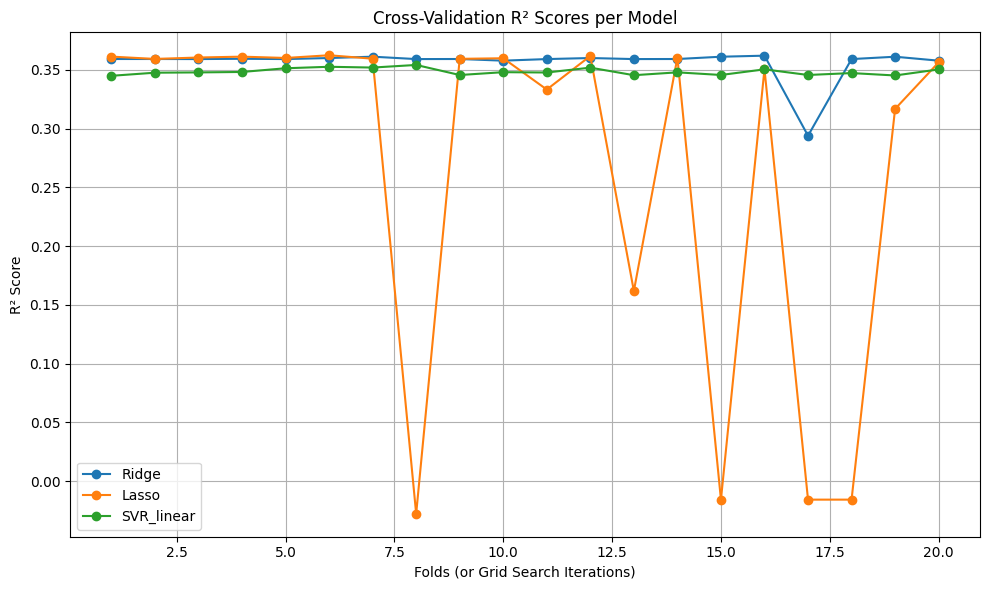


🏆 Best Model:
Model: Lasso
Mean CV R²: 0.3624
Best Hyperparameters: {'regressor__selection': 'cyclic', 'regressor__fit_intercept': True, 'regressor__alpha': np.float64(0.0069519279617756054)}


In [26]:
# Plot CV Scores
plt.figure(figsize=(10, 6))
for name, scores in l_cv_scores.items():
    x = range(1, len(scores) + 1) 
    if isinstance(scores, list):
        plt.plot(x, scores, label=f"{name} (manual)", marker='o')
    else:
        plt.plot(x, scores, label=f"{name}", marker='o')

plt.title("Cross-Validation R² Scores per Model")
plt.xlabel("Folds (or Grid Search Iterations)")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the best model summary
print("\n🏆 Best Model:")
print(f"Model: {l_best_model_name}")
print(f"Mean CV R²: {l_best_score:.4f}")
if l_best_params:
    print("Best Hyperparameters:", l_best_params)

# RESULTS

In [27]:
check_is_fitted(nl_best_model)

nl_best_model.fit(X_train, y_train)
y_pred = nl_best_model.predict(X_test)

rmse_bm = root_mean_squared_error(y_test, y_pred)
r2_bm = r2_score(y_test, y_pred)

print(f"R² score on the test set using the best model ({nl_best_model_name}): {r2_bm:.4f}")
print(f"RMSE score on the test set using the best model ({nl_best_model_name}): {rmse_bm:.4f}", "\n")

R² score on the test set using the best model (XGBRegressor): 0.4992
RMSE score on the test set using the best model (XGBRegressor): 0.9812 



In [28]:
nl_best_model

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('t_enc', ...), ('num', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


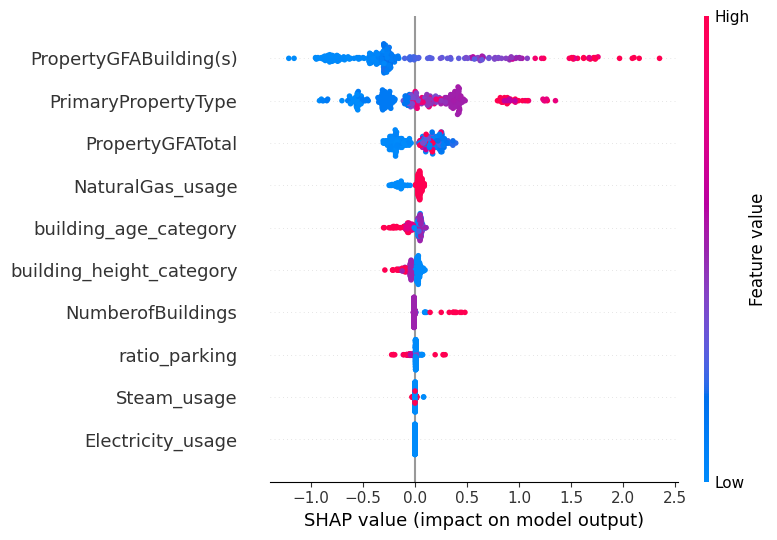

In [30]:
feature_names = ["PrimaryPropertyType", "PropertyGFABuilding(s)", "PropertyGFATotal", "building_age_category", "building_height_category",
                  "NumberofBuildings", "Electricity_usage", "NaturalGas_usage", "Steam_usage", "ratio_parking"]

# Get transformed data
X_transformed = nl_best_model[:-1].transform(X_test)

# Get the trained XGBRegressor from pipeline
xgb_model = nl_best_model.named_steps['regressor']  # adjust name if different

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)

# Plot summary
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

In [51]:
X_test.reset_index().iloc[94]

index                                491
NumberofBuildings                    1.0
PropertyGFATotal                 1952220
PropertyGFABuilding(s)           1632820
Electricity_usage                      1
NaturalGas_usage                       1
Steam_usage                            1
building_age_category          1980-1999
building_height_category             31+
ratio_parking                   0.163609
PrimaryPropertyType         Large Office
Name: 94, dtype: object

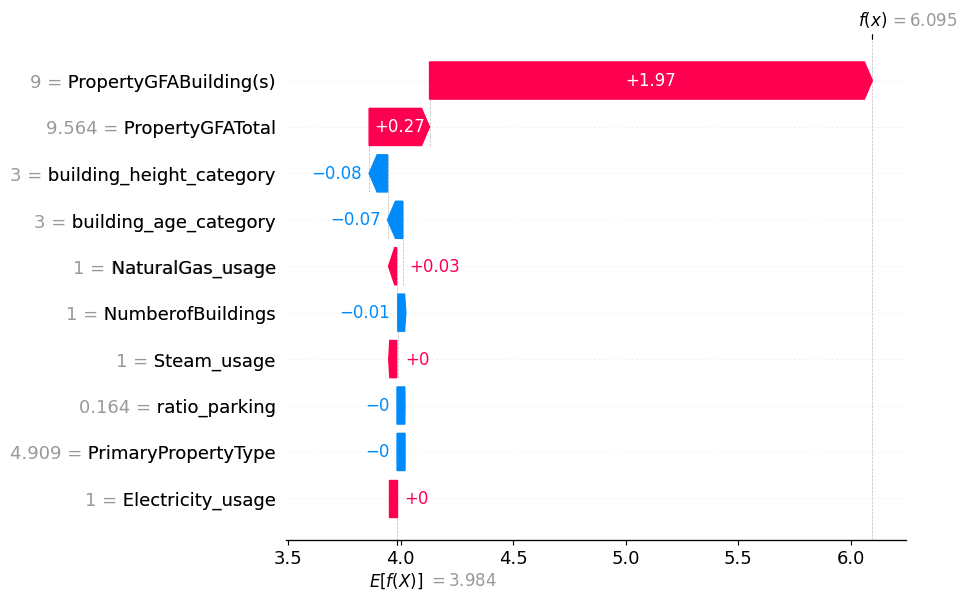

In [52]:
i = 94

shap_values_i = shap_values[i]
X_i = X_transformed[i]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_i,
        base_values=explainer.expected_value,
        data=X_i,
        feature_names=feature_names
    )
)

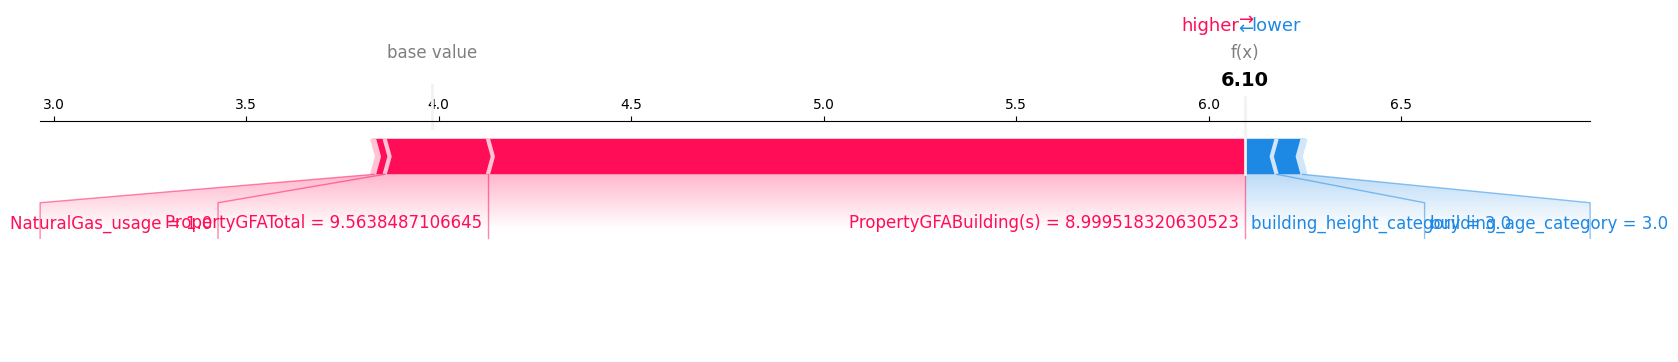

In [53]:
shap.force_plot(
    explainer.expected_value,
    shap_values_i,
    X_i,
    feature_names=feature_names,
    matplotlib=True
)

In [31]:
rfe = RFE(estimator=xgb_model, n_features_to_select=5, step=1)

X_train_trans = preprocessor.fit_transform(X_train, y_train)
X_test_trans = preprocessor.transform(X_test)

rfe.fit(X_train_trans, y_train)

print("Selected features mask:", rfe.support_)
print("Ranking of features:", rfe.ranking_)

score = rfe.score(X_test_trans, y_test)
print("Test R²:", score)

Selected features mask: [ True  True  True False  True False False  True False False]
Ranking of features: [1 1 1 2 1 4 6 1 5 3]
Test R²: 0.49625773822369723


In [ ]:
rfecv = RFECV(estimator=xgb_model, step=1, cv=5, scoring='r2')
rfecv.fit(X_train_trans, y_train)

plt.figure(figsize=(10,6))
plt.plot(range(1, len(rfecv.grid_scores_) + 1), rfecv.grid_scores_)
plt.xlabel("Nombre de features gardées")
plt.ylabel("Cross-validated R² score")
plt.title("R² vs Nombre de features (RFECV)")
plt.show()